# Задача
В этой работе вам предлагается решить задачу бинарной классификации, а именно построить алгоритм, определяющий превысит ли средний заработок человека порог $50k. Каждый объект выборки — человек, для которого известны следующие признаки:
 - age
 - workclass
 - fnlwgt
 - education
 - education-num
 - marital-status
 - occupation
 - relationship
 - race
 - sex
 - capital-gain
 - capital-loss
 - hours-per-week
 
Более подробно про признаки можно почитать [здесь](http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names). Целевой признак записан в переменной *>50K,<=50K*.

В этой задаче для обучения будут использовать 2 алгоритма:
 - [DecisonTree](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
 - [RandomForest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

# Решение

Загрузите набор данных *data.adult.csv* с помощью `pandas` (скачать можно [здесь](https://drive.google.com/file/d/1Lo47fXx1RrJG3v9E-Gck1T45n5bJ_SJf/view?usp=sharing), или с помощью скрипта ниже). Чтобы лучше понимать, с чем вы работаете/корректно ли вы загрузили данные можно вывести несколько первых строк на экран.

In [ ]:
import copy
!gdown 1Lo47fXx1RrJG3v9E-Gck1T45n5bJ_SJf

Downloading...
From: https://drive.google.com/uc?id=1Lo47fXx1RrJG3v9E-Gck1T45n5bJ_SJf
To: /content/data.adult.csv
100% 1.54M/1.54M [00:00<00:00, 141MB/s]


In [68]:
# your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score
#загружаем данные
df = pd.read_csv("data.adult.csv")
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,">50K,<=50K"
0,34,Local-gov,284843,HS-grad,9,Never-married,Farming-fishing,Not-in-family,Black,Male,594,0,60,<=50K
1,40,Private,190290,Some-college,10,Divorced,Sales,Not-in-family,White,Male,0,0,40,<=50K
2,36,Local-gov,177858,Bachelors,13,Married-civ-spouse,Prof-specialty,Own-child,White,Male,0,0,40,<=50K
3,22,Private,184756,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,<=50K
4,47,Private,149700,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,15024,0,40,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,25,Local-gov,514716,Bachelors,13,Never-married,Adm-clerical,Own-child,Black,Female,0,0,40,<=50K
16276,32,Private,207668,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,15024,0,45,>50K
16277,27,Private,104457,Bachelors,13,Never-married,Machine-op-inspct,Not-in-family,Asian-Pac-Islander,Male,0,0,40,<=50K
16278,59,State-gov,268700,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,<=50K


## Анализ и предобработка данных

Обычно после загрузки датасета всегда необходима его некоторая предобработка. В данном случае она будет заключаться в следующем: 
1. Проверьте есть ли в данных пропущенные значения (здесь они обозначены как "?"). Удалите из выборки все объекты с пропусками.
2. Выделите 60% выборки для обучения и дальнейшего анализа.
3. Обратите внимание, что не все признаки являются вещественными (числовыми). Сначала их необходимо проанализировать и по необходимости предобработать. Все шаги предобработки поясните текстом.
4. Целевую переменную (ту, которую мы хотим предсказывать) можно выделить в отдельную переменную и преобразуйте к бинарному формату (НЕ забудьте удалить ее из датасета, когда будете обучать модель).


In [69]:
# your code here
#чистим строки от ?, заменяем на Nan
df = df.replace('?', np.nan)
df.dropna(inplace=True)
#выделим целевой признак. Он в столбце `>50K,<=50K`. преобразуем его в 0 (меньше равно 50к) и 1 (больше 50к)
df['target'] = df['>50K,<=50K'].apply(lambda x: 1 if x == '>50K' else 0)
y = df['target'].copy()
df.drop(columns=['target'], inplace=True)
df.drop(columns=['>50K,<=50K'], inplace=True)     
for col in df:
    if pd.api.types.is_numeric_dtype(df[col]) == False:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])       
#Выделение 60% выборки для обучения и дальнейшего анализа
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.4, random_state=42)


При обучении алгоритмов стоит обращать внимание не только на их качество, но и каким образом они работают с данными. Давайте посмотрим на значения самих признаков.

Что можете сказать о разбросе данных и сбалансированности выборки? В каком диапазоне лежат исследуемые признаки?

## Добавление категориальных признаков

Добавим к предобработанным вещественным признакам категориальные. Но для начала их тоже необходимо предобработать.

Преобразуйте все категориальные признаки с помощью метода one-hot-encoding (например, это можно сделать с помощью функции [pandas.get_dummies](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html) или [DictVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.DictVectorizer.html) / [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) из sklearn).

После преобразования категориальных признаков, добавьте их к вещественным предобработанным данным для обучения.

>PS Напоминаю, что важно удалить колонку с целевым значением

In [70]:
# your code here

## Обучение классификаторов

В начале посмотрим, как работает подбор параметров по сетке и как влияет на качество разбиение выборки. Сейчас и далее будем рассматривать 2 алгоритма:
 - [DecisonTree](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
 - [RandomForest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

Для начала обучим  выберем один гиперпараметр, который будем оптимизировать, — глубина дерева (*max_depth*).
 
Остальные параметры оставляйте в значениях по умолчанию.

Для каждого алгоритма подберите оптимальные значения указанных гиперпараметров. Постройте график среднего значения качества по кросс-валидации алгоритма при заданном значении гиперпараметра, на котором также отобразите доверительный интервал.

Что вы можете сказать о получившихся графиках? Какой алгоритм справился лучше? Какой быстрее? Почему?

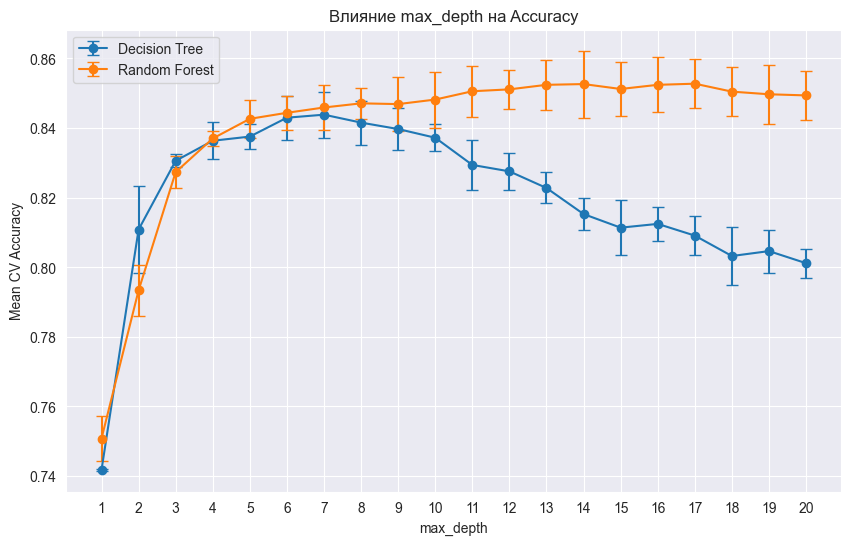

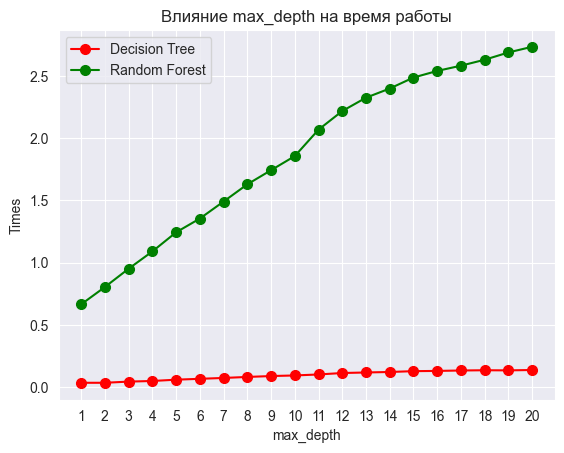

Лучший max_depth для Decision Tree: 7, CV-Accuracy = 0.8438
Лучший max_depth для Random Forest: 17, CV-Accuracy = 0.8527


In [71]:
# your code here
import time
param_grid['max_depth'] = [i for i in range(1, 21)]
dt_scores_mean = []
dt_scores_std  = []

rf_scores_mean = []
rf_scores_std  = []

dt_times = []
rf_times = []
for depth in param_grid['max_depth']:
    start_time = time.time()
    dt_clf = DecisionTreeClassifier(max_depth=depth)
    scores = cross_val_score(dt_clf, X_train, y_train, scoring='accuracy')
    end_time = time.time()
    elapsed_time = end_time - start_time
    dt_times.append(elapsed_time)
    dt_scores_mean.append(scores.mean())
    dt_scores_std.append(scores.std())
    
    # Random Forest
    start_time = time.time()
    rf_clf = RandomForestClassifier(max_depth=depth)
    scores2 = cross_val_score(rf_clf, X_train, y_train, scoring='accuracy')
    end_time = time.time()
    elapsed_time = end_time - start_time
    rf_times.append(elapsed_time)
    rf_scores_mean.append(scores2.mean())
    rf_scores_std.append(scores2.std())   

# Визуализируем
x_vals = range(len(param_grid['max_depth']))  # индексы для графика

plt.figure(figsize=(10, 6))
# Decision Tree
plt.errorbar(x_vals, dt_scores_mean, yerr=dt_scores_std, label='Decision Tree', capsize=4, marker='o')
# Random Forest
plt.errorbar(x_vals, rf_scores_mean, yerr=rf_scores_std, label='Random Forest', capsize=4, marker='o')

plt.xticks(x_vals, [str(md) for md in param_grid['max_depth']])
plt.xlabel('max_depth')
plt.ylabel('Mean CV Accuracy')
plt.title('Влияние max_depth на Accuracy')
plt.legend()
#усики графиков показывают доверительный интервал
plt.show()

plt.plot(x_vals, dt_times, color='red', marker='o', markersize=7, label='Decision Tree')
plt.plot(x_vals, rf_times, color='green', marker='o', markersize=7, label='Random Forest')
plt.xticks(x_vals, [str(md) for md in param_grid['max_depth']])
plt.xlabel('max_depth')
plt.ylabel('Times')
plt.title('Влияние max_depth на время работы')
plt.legend()
plt.show()
# Найдём, при каком max_depth достигается максимум
best_dt_depth_index = np.argmax(dt_scores_mean)
best_dt_depth = param_grid['max_depth'][best_dt_depth_index]
print(f"Лучший max_depth для Decision Tree: {best_dt_depth}, CV-Accuracy = {dt_scores_mean[best_dt_depth_index]:.4f}")

best_rf_depth_index = np.argmax(rf_scores_mean)
best_rf_depth = param_grid['max_depth'][best_rf_depth_index]
print(f"Лучший max_depth для Random Forest: {best_rf_depth}, CV-Accuracy = {rf_scores_mean[best_rf_depth_index]:.4f}")
#при этом Random Forest значительно медленнее работает чем Decision Tree

Далее произведем подбор других гиперпараметров алгоритмов. Начнет со случайного леса. Для начала подберём число деревьев (*n_estimators*) в алгоритме RandomForest. Как известно, в общем случае Random Forest не переобучается с увеличением количества деревьев. Подберите количество деревьев, начиная с которого качество на кросс-валидации стабилизируется. Обратите внимание, что для проведения этого эксперимента не нужно с нуля обучать много случайных лесов с различными количествами деревьев. Обучите один случайный лес с максимальным интересным количеством деревьев, а затем рассмотрите подмножества деревьев разных размеров, состоящих из деревьев построенного леса (поле [*estimators_*](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)). В дальнейших экспериментах используйте подобранное количество деревьев.

Максимальное n_estimators при котором качество кросвалидации стабилизируется  33


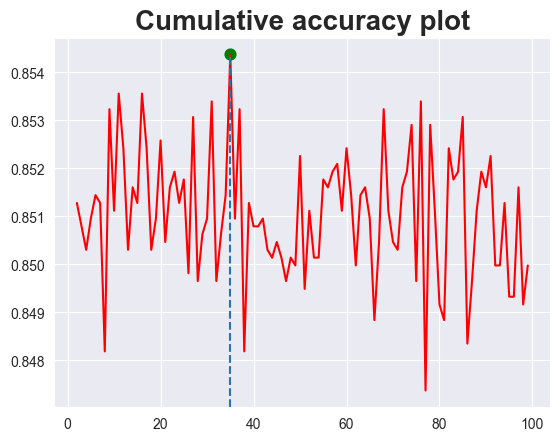

In [93]:
# your code here
import copy
rf_clf = RandomForestClassifier(max_depth=15, n_estimators=100)
rf_clf.fit(X_train, y_train)
model_accs = [] 
#находим точность каждого из деревьев этого леса
for idx, tree in enumerate(rf_clf.estimators_):
    score = cross_val_score(tree, X_train, y_train, scoring='accuracy')
    model_accs.append([idx, score.mean()]) 
model_accs = np.array(model_accs)
#пересортируем порядок деревьев по качеству score
sorted_idx = np.argsort(model_accs[:, 1])[::-1]
model_idx = model_accs[sorted_idx][:,0].astype(int)
rf_clf.estimators_ = np.array(rf_clf.estimators_)[model_idx].tolist()
#сравним accuracy пересортированных моделей
result = []
for i in range(2, len(rf_clf.estimators_)):
    small_model = copy.deepcopy(rf_clf)
    small_model.estimators_ = rf_clf.estimators_[:i]
    scores = cross_val_score(small_model, X_train, y_train, scoring='accuracy')
    result.append([i, scores.mean()])
    
result = np.array(result)
max_index = np.argmax(result[:, 1])
print('Максимальное n_estimators при котором качество кросвалидации стабилизируется ',max_index)
fig, ax = plt.subplots()
ax.plot(result[:, 0], result[:, 1], c = 'red')
ax.axvline(x=result[max_index][0], ymax=0.95, ls = "--")
plt.scatter([result[max_index][0],], [result[max_index][1],], zorder=0, s=60, c = 'green')

ax.set_title("Cumulative accuracy plot", fontsize = 20, fontweight = "bold")
plt.show()

Теперь подберите следующие оптимальные параметры:
- максимальная глубина решающего дерева (*max_depth*)
- функция оценки качества разбиения (*criterion*)
- максимальное количесво учитываемых признаков при разбиении (*max_features*)

Остальные параметры оставляйте по умолчанию, за исключением парамтра `n_estimators` для случайного леса, выбранного на предыдущем шаге.

Оцените скорость обучения каждого из алгоритмов. Для этого воспользуйтесь графиком вида "ящик с усами", который отражает среднее время обучения алгоритма при фиксированном значении гиперпараметров. Что вы можете сказать о скорости работы алгоритмов? Почему наблюдаются такие результаты? Можно ли ускорить? Если да, то каким образом?

In [100]:
# your code here
#используем решетчатый поиск для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV
n_features = X_train.shape[1]
param_grid1 = {
    'max_depth': [i for i in range(1, 21)],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': [i for i in range(1, n_features)]
}
rf_model = RandomForestClassifier(n_estimators=33)
grid_search = GridSearchCV(rf_model, param_grid1, cv=5)
grid_search.fit(X_train, y_train)
print("RandomForestClassifier Best Hyperparameters:", grid_search.best_params_)
print("RandomForestClassifier Best Cross-Validation Score:", grid_search.best_score_)
dt_model = DecisionTreeClassifier()
grid_search = GridSearchCV(dt_model, param_grid1, cv=5)
grid_search.fit(X_train, y_train)
print("DecisionTreeClassifier Best Hyperparameters:", grid_search.best_params_)
print("DecisionTreeClassifier Best Cross-Validation Score:", grid_search.best_score_)

RandomForestClassifier Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 15, 'max_features': 3}
RandomForestClassifier Best Cross-Validation Score: 0.8545814630084084
DecisionTreeClassifier Best Hyperparameters: {'criterion': 'gini', 'max_depth': 8, 'max_features': 11}
DecisionTreeClassifier Best Cross-Validation Score: 0.844048194078538


## Сравнение результатов

Сравните результаты алгоритмво. Для этого воспользуйтесь "ящиком с усами" (boxplot).

Сделайте общие итоговые выводы о классификаторах с точки зрения их работы с признаками и сложности самой модели (какие гиперпараметры есть у модели, сильно ли изменение значения гиперпараметра влияет на качество модели).

In [ ]:
# your code here

## Тестирование всех модели

Протестируйте последние построенные модели (наилучшее решающее дерево и наилучший случайный лес) на данных, которые были отложены для теста (их должно было остаться 40%). Не забудьте про все необходимые преобразования.

In [104]:
# your code here
best_dt_model = DecisionTreeClassifier(criterion='gini', max_depth = 8, max_features=11)
best_dt_model.fit(X_train, y_train)
best_dt_pred = best_dt_model.predict(X_test)
print('DecisionTree Accuracy ', accuracy_score(y_test, best_dt_pred))
print('DecisionTree F1 score ', f1_score(y_test, best_dt_pred))
best_rf_model = RandomForestClassifier(n_estimators=33, criterion='entropy', max_features=3, max_depth=15)
best_rf_model.fit(X_train, y_train)
best_rf_pred = best_rf_model.predict(X_test)
print('RandomForest Accuracy ', accuracy_score(y_test, best_rf_pred))
print('RandomForest F1 score ', f1_score(y_test, best_rf_pred))

DecisionTree Accuracy  0.8494868871151653
DecisionTree F1 score  0.648936170212766
RandomForest Accuracy  0.852418960742792
RandomForest F1 score  0.6789510985116939
